In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
# Load the dataset
csv_path = '/Users/dhruvipanchasara/Documents/ds-studio-ii/BMW sales data (2010-2024).csv' 

df = pd.read_csv(csv_path)

In [44]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [45]:
#It shows how many values are present in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [46]:
# provides summary of statistics for numerical columns
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [47]:
#gives the number of rows and columns
df.shape

(50000, 11)

In [48]:
#shows the missing values in each column
df.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [49]:
#shows that there are no duplicates in the dataset
# df.duplicated() returns a boolean Series (True for duplicates, False for unique/first)
# df[...] applies this to filter the original DataFrame
df[df.duplicated()]

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification


In [50]:
keep_region = ['Asia', 'Europe', 'North America']
df = df[df['Region'].isin(keep_region)] # Filter the Dataset to keep only rows where 'Region' is in the keep_region list
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High
7,M5,2014,Asia,Black,Diesel,Automatic,1.6,121156,102778,632,Low
...,...,...,...,...,...,...,...,...,...,...,...
49993,5 Series,2013,Europe,Grey,Petrol,Manual,4.7,155013,80263,3700,Low
49994,5 Series,2010,North America,Silver,Petrol,Manual,3.6,56672,32990,1575,Low
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [51]:
# Select columns in the DataFrame 'df' that have the data type "object" (typically strings or mixed types)
# The select_dtypes() method filters columns based on their data type.
# The '.columns' attribute then extracts the names of these selected columns into an Index object.
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Sales_Classification'],
      dtype='object')

In [60]:
# x is the input of any data type, including None
def remove_whitespace(x):
    if x is None:
        return None
    
    x = str(x).strip() #strip removes the whitespace from the beginning and end of the string
    return x
    
# remove_extra_whitespace
# Apply the 'remove_whitespace' function to every single cell within the current column
# Iterate through each column in the Dataset
for col in df.columns:
    df[col] = df[col].apply(remove_whitespace) 
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High
7,M5,2014,Asia,Black,Diesel,Automatic,1.6,121156,102778,632,Low
...,...,...,...,...,...,...,...,...,...,...,...
49993,5 Series,2013,Europe,Grey,Petrol,Manual,4.7,155013,80263,3700,Low
49994,5 Series,2010,North America,Silver,Petrol,Manual,3.6,56672,32990,1575,Low
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [52]:
df.shape

(25123, 11)

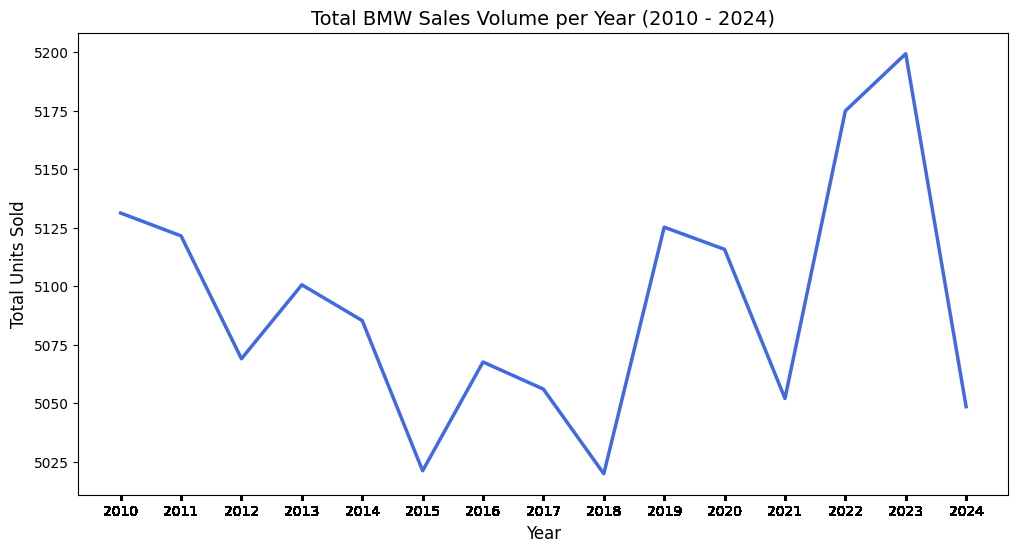

In [65]:
# Convert Year and Sales_Volume to numeric types
df['Year'] = pd.to_numeric(df['Year'])
df['Sales_Volume'] = pd.to_numeric(df['Sales_Volume'])

# Create a figure object with specific width (12) and height (6) in inches
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df, 
    x='Year', 
    y='Sales_Volume',  
    color='royalblue', 
    linewidth=2.5, errorbar=None
)

plt.title('Total BMW Sales Volume per Year (2010 - 2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)

# Ensure every year is labeled on the X-axis
plt.xticks(df['Year'])

plt.show()

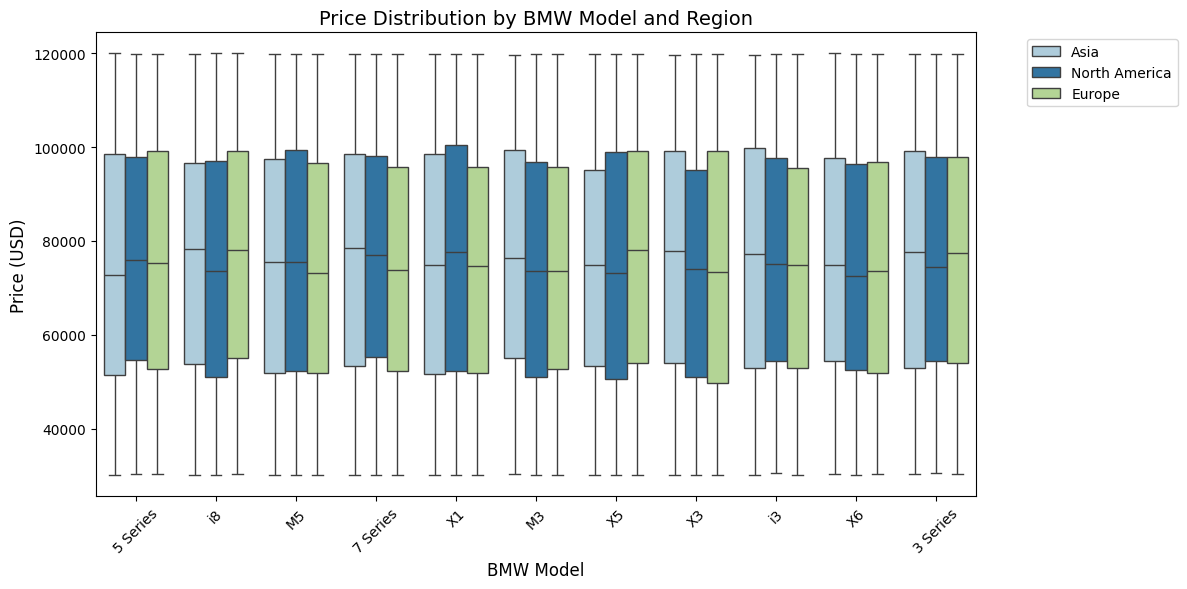

In [66]:
# Set figure size
plt.figure(figsize=(12,6))

#convert string to numeric 
df['Price_USD'] = pd.to_numeric(df['Price_USD'])

# relation between model of the car and price across different regions.
sns.boxplot(
    data=df,
    x='Model',
    y='Price_USD',
    hue='Region', #hue is for sub-groups/colors the boxes based on Region
    palette='Paired'
)

# Rotate x-axis labels by 45 degrees to prevent overlapping text
plt.xticks(rotation=45)

# bbox_to_anchor=(1.05, 1) positions it outside, loc='upper left' aligns the legend box
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside top right
plt.title('Price Distribution by BMW Model and Region', fontsize=14)
plt.xlabel('BMW Model', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.tight_layout()
plt.show()

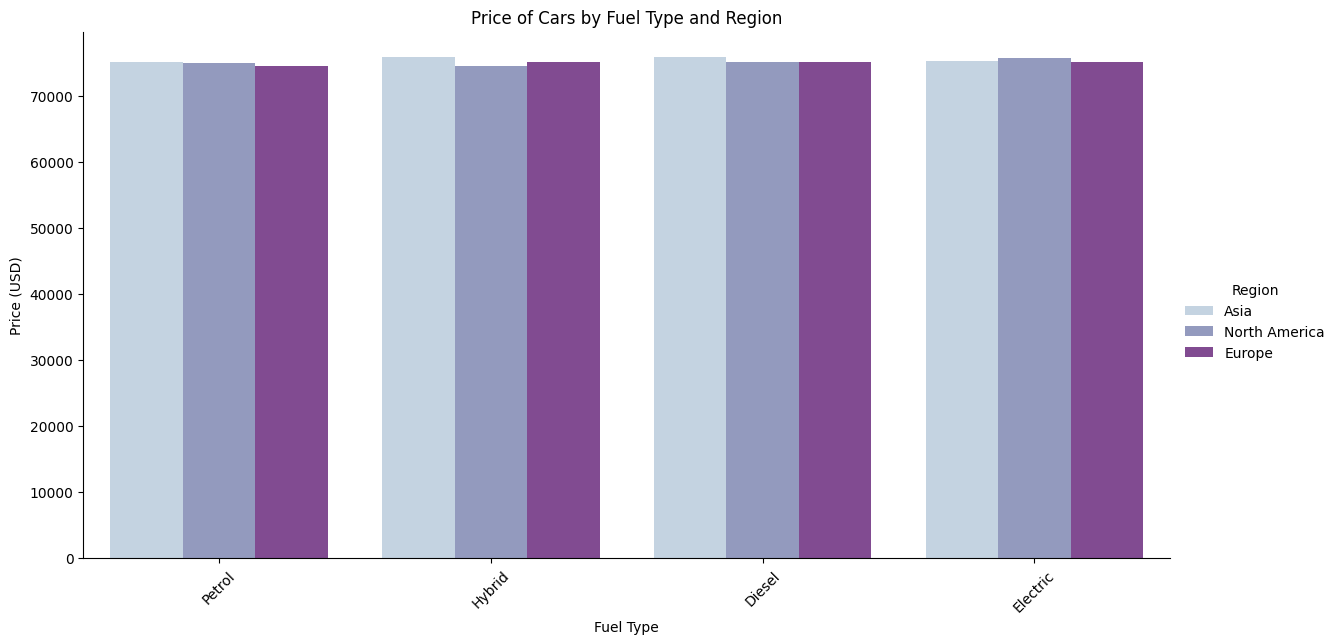

In [67]:
#convert string to numeric 
df['Price_USD'] = pd.to_numeric(df['Price_USD'])

#relation between fuel type and price across different regions
g = sns.catplot(
	data=df,
	kind='bar',
	x='Fuel_Type',
	y='Price_USD',
	errorbar=None,
	palette='BuPu',
	height=6,
	aspect=2, hue= 'Region' # Set the aspect ratio (width/height) to make it wider
)
plt.title('Price of Cars by Fuel Type and Region')
plt.xlabel('Fuel Type')
plt.ylabel('Price (USD)')

# Rotate the x-axis labels by 45 degrees to prevent overlapping
plt.xticks(rotation=45)

plt.show()

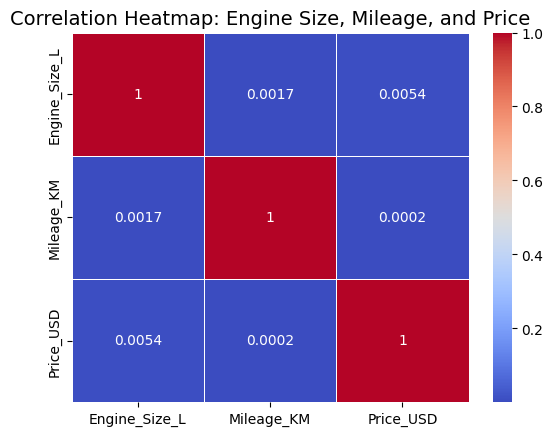

In [68]:
#correlation between engine size, mileage and price
#annot=True: Displays the correlation coefficient values inside each cell
#linewidths=0.5: Adds a thin line between cells to improve readability
sns.heatmap(df[['Engine_Size_L', 'Mileage_KM', 'Price_USD']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: Engine Size, Mileage, and Price', fontsize=14)
plt.show()